$$\renewcommand{\ket}[1]{\left|{#1}\right\rangle}$$
$$\renewcommand{\bra}[1]{\left\langle{#1}\right|}$$

# 量子状態と量子論理ゲートの基礎
量子計算は通常、量子ビットと呼ばれる複数の2準位量子力学系からなる量子状態を初期化し、それにいくつかの量子論理ゲートを作用させ、最後に測定を行うことで実行されます。

状態が物理系としてどのように実装されるかは、個々の量子コンピュータのアーキテクチャに依存しており、量子ゲートや測定についても同様です。

以下では、量子ビットによって量子状態がどのように表現され、量子論理ゲートがどのように作用するのかを詳しく見ていきます。

## 量子ビットと量子状態
量子ビットとは、通常 $\ket{0}$ と $\ket{1}$ という記号で表される2つの準位を持つ量子系です。量子系であるため、1量子ビットの一般的な状態 $\ket{\psi}$ は、複素係数 $\alpha$ と $\beta$ を用いてこれら2つの基底状態の線形結合として表されます。

$$
\ket{\psi} = \alpha \ket{0} + \beta \ket{1}
$$

状態ベクトルは規格化されているため、係数は $|\alpha|^2 + |\beta|^2 = 1$ を満たします。また、$\ket{\psi}$ 全体の位相因子は物理的には無関係です。したがって、常に $\alpha$ の位相を実数に選ぶことができます。

$\alpha$ と $\beta$ を実数の角度パラメータ $\theta$ と $\phi$ で表すと便利です。
$$
\alpha = \cos(\frac{\theta}{2}),~ \beta = e^{i\phi}\sin(\frac{\theta}{2})
$$

これは、1量子ビットが球面上の1点として表現できることを意味します。この球はブロッホ球と呼ばれます。量子ビットが表す量子状態は0と1だけに限られず、この球面上の任意の点を取ることができます。

やや抽象的な状態ベクトル $\ket{\psi}$ も、量子ビットのベクトル空間の基底を $\ket{0}$ と $\ket{1}$ に固定すれば、より具体的な複素成分を持つ行ベクトルとして表現できます。

$$
\ket{0} = \begin{bmatrix}1\\0\end{bmatrix}, \ket{1} = \begin{bmatrix}0\\1\end{bmatrix}
$$

このようにして、$\ket{\psi}$ も複素行ベクトルとして表されます。

$$
\ket{\psi} = \alpha \ket{0} + \beta \ket{1} = \alpha \begin{bmatrix}1\\0\end{bmatrix} + \beta \begin{bmatrix}0\\1\end{bmatrix} = \begin{bmatrix}\alpha \\ \beta \end{bmatrix}.
$$

この基底の選び方が最も一般的に使われるもので、計算基底と呼ばれます。

## 初期状態
初期状態の最も単純な選び方は次のようになります。

$$
\ket{0} = \begin{bmatrix}1\\0\end{bmatrix}
$$

これはBlueqatツールキットにおける初期状態ベクトルのデフォルトの選択であり、明示的に別の状態に初期化しない限り暗黙的に使用されます。


## 回転としての量子ゲート

量子状態は、最終的な結果を得るために測定される前に、特定の目的のために構成された量子回路によって変更されます。

量子回路を構成する部品は量子ゲートであり、数学的には量子状態にユニタリ変換を引き起こすことから、しばしばユニタリゲートとも呼ばれます。

ユニタリ変換は複素ベクトル空間における回転の一般化です。1量子ビットに対するユニタリ変換は、物理的に無関係な全体位相因子を除けば、ブロッホ球のX軸、Y軸、Z軸周りの回転から構成されます。

これら3つの基本的な回転操作は、パウリゲートとしても知られるX、Y、Zゲートによって生成されます。

$$
X=
\begin{bmatrix}
0&1 \\
1&0
\end{bmatrix},
Y=
\begin{bmatrix}
0&-i \\
i&0
\end{bmatrix},
Z=
\begin{bmatrix}
1&0 \\
0&-1
\end{bmatrix}
$$

これらの軸周りの回転は、それらの指数関数として表されます。

$$
R_x(\theta) = e^{-\frac{i\theta}{2}X},~
R_y(\theta) = e^{-\frac{i\theta}{2}Y},~
R_z(\theta) = e^{-\frac{i\theta}{2}Z}
$$

量子計算で頻繁に使われる基本的な量子ゲートは他にもいくつかあります。以下の例で、Blueqatツールキットを使ってそれらが回転ゲートとともにどのように動作するかを見ていきましょう。より詳しい入門については[3]を参照してください。

# Blueqat クイックスタート
## インストール
以下はBlueqat量子計算ツールキットの基本的な機能を簡単に紹介するものです。まだインストールしていない場合は、他のPythonパッケージと同様にblueqatパッケージをインストールしてください。

In [1]:
!pip install git+https://github.com/blueqat/blueqatSDK

/Users/yuichirominato/.pyenv/shims/pip: line 8: /opt/homebrew/opt/pyenv/bin/pyenv: No such file or directory


## ステップ1: 基本的な回路を用意する
量子コンピュータで計算を実行するには、量子回路のインスタンスを作成する必要があります。Blueqatツールキットの主要なコンポーネントをインポートし、インスタンス化しましょう。量子状態は暗黙的に $\ket{0}$ に初期化されます。

In [2]:
from blueqat import Circuit

#initialization of circuit
Circuit()

Circuit(0).

## ステップ2: 回路に量子論理ゲートを作用させる
次に、回路にいくつかの量子論理ゲートを配置します。
初期化した回路からメソッドチェーンでゲートを繋げていくことができます。例の `.x[0]` は、0番目の量子ビットにXゲートを作用させることを意味します。

In [3]:
Circuit().x[0]

Circuit(1).x[0]

## ステップ3: 測定
この回路の結果を得るには、測定を行う必要があります。`.m[:]` として測定ゲートを付加しましょう。`:` はすべての量子ビットに測定ゲートを作用させることを示します。このコロン記法はnumpy配列の記法から借用されています。この小さな例では `.m[0]` でも同じ結果が得られます。Blueqatツールキットでは、測定は常にZ基底で行われます。つまり、結果は常に0か1になります。

In [4]:
Circuit().x[0].m[:]

Circuit(1).x[0].measure[:]

## ステップ4: 回路の実行
最後に、`.run()` メソッドを付加して、この回路が指定する量子計算プロセスを実際に実行します。量子測定の結果は確率変数であり、実行するたびに得られる値は変動するため、通常は結果を平均化して見るために複数回実行する必要があります。`run()` メソッドの "shots" 引数で実行回数を指定できます。現在、結果はデフォルトでPythonのCounterオブジェクトとして返され、結果の分布を示します。

In [5]:
Circuit().x[0].m[:].run(shots=1)

Counter({'1': 1})

'1' という結果が一度得られるはずです。通常、回路は0から始まり、この例ではXゲートを適用することで量子ビットが1に反転します。そのため、最終結果として1が得られます。

また、`run()` メソッドに `backend="draw"` オプションを与えることで、回路を図として表示することもできます。

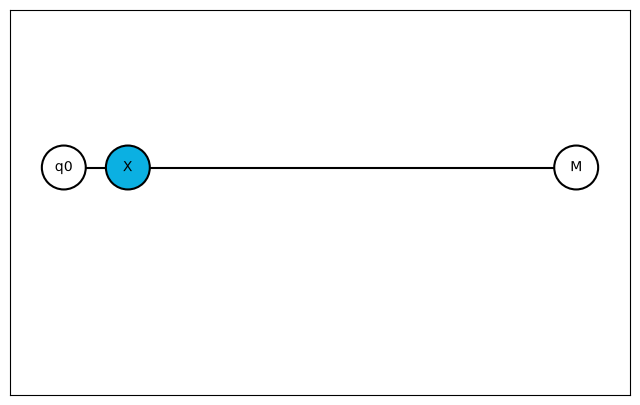

({0: [{'num': 0,
    'gate': 'q0',
    'angle': '',
    'xpos': 0,
    'ypos': 0.0,
    'type': 'qubit'},
   {'num': 1,
    'gate': 'X',
    'angle': '',
    'xpos': 1,
    'ypos': 0.0,
    'type': 'gate'},
   {'num': 2,
    'gate': 'M',
    'angle': '',
    'xpos': 8,
    'ypos': 0.0,
    'type': 'measurement'}]},
 1,
 [1, 2],
 [1, 2],
 [],
 [])

In [6]:
Circuit().x[0].m[:].run(backend="draw")

## 基本的な2量子ビット操作
ここでは基本的な2量子ビット操作について学びます。2量子ビット操作により、より複雑な計算が可能になり、量子ビット間に相関を作ることで様々なアルゴリズムを実装できるようになります。

## 回路の作成と実行
回路の準備は1量子ビットの例と同じです。回路をインスタンス化する際に量子ビット数を明示的に設定する必要はありません。Blueqatツールキットは回路の構造をチェックし、計算の実行に必要な量子ビット数を決定します。
この例では、量子ビット0と1に作用するCXゲートを使うため、これは2量子ビットの回路になります。

In [7]:
Circuit().cx[0,1].m[:].run(shots=1)

Counter({'00': 1})

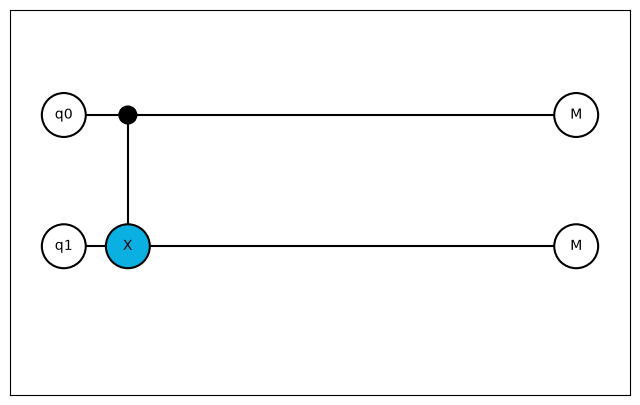

({0: [{'num': 0,
    'gate': 'q0',
    'angle': '',
    'xpos': 0,
    'ypos': 0.0,
    'type': 'qubit'},
   {'num': 3, 'gate': '', 'angle': '', 'xpos': 1, 'ypos': 0.0, 'type': 'gate'},
   {'num': 4,
    'gate': 'M',
    'angle': '',
    'xpos': 8,
    'ypos': 0.0,
    'type': 'measurement'}],
  1: [{'num': 1,
    'gate': 'q1',
    'angle': '',
    'xpos': 0,
    'ypos': 1.5,
    'type': 'qubit'},
   {'num': 2,
    'gate': 'X',
    'angle': '',
    'xpos': 1,
    'ypos': 1.5,
    'type': 'gate'},
   {'num': 5,
    'gate': 'M',
    'angle': '',
    'xpos': 8,
    'ypos': 1.5,
    'type': 'measurement'}]},
 2,
 [2, 4],
 [1, 2],
 [(2, 3)],
 [])

In [8]:
Circuit().cx[0,1].m[:].run(backend="draw")

'00' という結果が一度得られます。00は両方の量子ビットが0であることを意味します。

## CXゲート
CX量子論理ゲートは、コントロールXゲート、コントロールNOTゲート、あるいは略してCNOTゲートと呼ばれます。このゲートは2つの量子ビットに作用します。
一方は「制御量子ビット」、もう一方は「対象量子ビット」と呼ばれます。制御量子ビットが'1'のときのみ、対象量子ビットが反転します。制御ゲートが'0'であれば対象量子ビットは変化しません。
この例では、両方の量子ビットが0に初期化されているため、CXゲートを適用した後も対象量子ビットは0のままです。最初のインデックスで指定された量子ビットが制御量子ビットとして、2番目のインデックスが対象量子ビットとして働きます。

## CXゲートの続き

制御量子ビットが1の場合に何が起こるか見てみましょう。Xゲートを適用してそれを反転させ、その後、量子ビット0と1にCXゲートを適用します。

In [9]:
Circuit().x[0].cx[0,1].m[:].run(shots=1)

Counter({'11': 1})

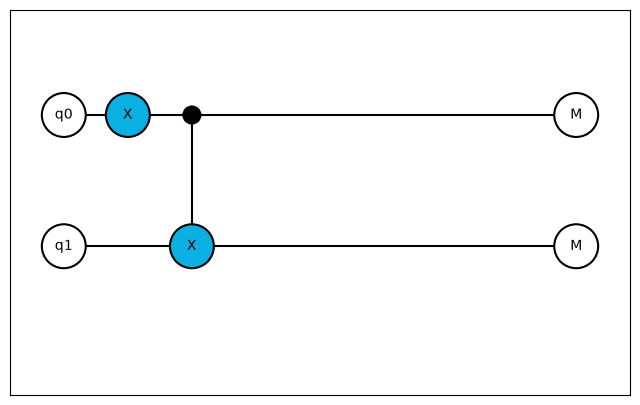

({0: [{'num': 0,
    'gate': 'q0',
    'angle': '',
    'xpos': 0,
    'ypos': 0.0,
    'type': 'qubit'},
   {'num': 2,
    'gate': 'X',
    'angle': '',
    'xpos': 1,
    'ypos': 0.0,
    'type': 'gate'},
   {'num': 4, 'gate': '', 'angle': '', 'xpos': 2, 'ypos': 0.0, 'type': 'gate'},
   {'num': 5,
    'gate': 'M',
    'angle': '',
    'xpos': 8,
    'ypos': 0.0,
    'type': 'measurement'}],
  1: [{'num': 1,
    'gate': 'q1',
    'angle': '',
    'xpos': 0,
    'ypos': 1.5,
    'type': 'qubit'},
   {'num': 3,
    'gate': 'X',
    'angle': '',
    'xpos': 2,
    'ypos': 1.5,
    'type': 'gate'},
   {'num': 6,
    'gate': 'M',
    'angle': '',
    'xpos': 8,
    'ypos': 1.5,
    'type': 'measurement'}]},
 2,
 [2, 3, 5],
 [1, 2, 3],
 [(3, 4)],
 [])

In [10]:
Circuit().x[0].cx[0,1].m[:].run(backend="draw")

これで結果は '11' になりました。まず、`.x[0]` ゲートによって回路が0番目(制御)の量子ビットを1に反転させ、次に `.cx[0,1]` ゲートが1番目(対象)の量子ビットを0から1に反転させ、両方の量子ビットが1になります。

## 発展的なトピック
## 量子ビット数を指定して回路を初期化する
通常、回路は自身が使用する量子ビット数を自動的に決定しますが、作成時に量子ビット数を指定することもできます。

そのためには、`Circuit()` メソッドの引数として量子ビット数を指定します。以下の例では3量子ビットが用意され、そのうち2つだけが使用されます。

In [11]:
Circuit(3).x[0].cx[0,1].m[:].run(shots=1)

Counter({'011': 1})

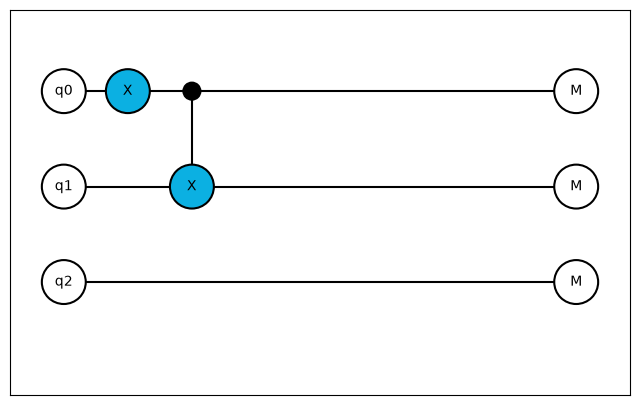

({0: [{'num': 0,
    'gate': 'q0',
    'angle': '',
    'xpos': 0,
    'ypos': 0.0,
    'type': 'qubit'},
   {'num': 3,
    'gate': 'X',
    'angle': '',
    'xpos': 1,
    'ypos': 0.0,
    'type': 'gate'},
   {'num': 5, 'gate': '', 'angle': '', 'xpos': 2, 'ypos': 0.0, 'type': 'gate'},
   {'num': 6,
    'gate': 'M',
    'angle': '',
    'xpos': 8,
    'ypos': 0.0,
    'type': 'measurement'}],
  1: [{'num': 1,
    'gate': 'q1',
    'angle': '',
    'xpos': 0,
    'ypos': 1.5,
    'type': 'qubit'},
   {'num': 4,
    'gate': 'X',
    'angle': '',
    'xpos': 2,
    'ypos': 1.5,
    'type': 'gate'},
   {'num': 7,
    'gate': 'M',
    'angle': '',
    'xpos': 8,
    'ypos': 1.5,
    'type': 'measurement'}],
  2: [{'num': 2,
    'gate': 'q2',
    'angle': '',
    'xpos': 0,
    'ypos': 3.0,
    'type': 'qubit'},
   {'num': 8,
    'gate': 'M',
    'angle': '',
    'xpos': 8,
    'ypos': 3.0,
    'type': 'measurement'}]},
 3,
 [3, 4, 6],
 [1, 2, 3],
 [(4, 5)],
 [])

In [12]:
Circuit(3).x[0].cx[0,1].m[:].run(backend="draw")

# 重ね合わせ
ここでは量子的な重ね合わせの基本的な例を見ます。重ね合わせとは、数学的には単に基底状態ベクトルの線形結合です。

## 回路
重ね合わせの実装は非常に簡単です。暗黙的に $\ket{0}$ に初期化されている量子ビットにアダマールゲート(Hゲート)を適用するだけです。
$$ H = 
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1 & 1\\
1 & -1
\end{bmatrix}
$$
 Hゲートは状態を $(\ket{0} + \ket{1})/\sqrt{2}$ に変換します。この状態を測定して結果が0か1かを見ると、それぞれ0.5の等しい確率で得られます。
結果を見るために、回路を100回実行します。

In [13]:
Circuit().h[0].m[:].run(shots=100)

Counter({'1': 56, '0': 44})

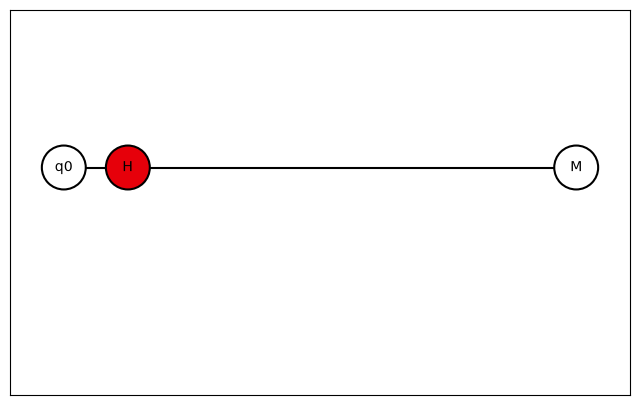

({0: [{'num': 0,
    'gate': 'q0',
    'angle': '',
    'xpos': 0,
    'ypos': 0.0,
    'type': 'qubit'},
   {'num': 1,
    'gate': 'H',
    'angle': '',
    'xpos': 1,
    'ypos': 0.0,
    'type': 'gate'},
   {'num': 2,
    'gate': 'M',
    'angle': '',
    'xpos': 8,
    'ypos': 0.0,
    'type': 'measurement'}]},
 1,
 [1, 2],
 [1, 2],
 [],
 [])

In [14]:
Circuit().h[0].m[:].run(backend="draw")

0と1がほぼ半々の結果で得られます。実際の数はランダム性により正確な50:50から多少ばらつきますが、0と1がどちらも $(\frac{1}{\sqrt{2}})^2 = 0.5$ の確率であることと一致しています。

## エンタングルメント
エンタングルメント(量子もつれ)は、2つ以上の量子系の間の相関の源です。例として、次の2量子ビット量子状態を考えます。

$$
\ket{\psi} = (\ket{00} + \ket{11})/\sqrt{2}
$$

上記で、$\ket{00}$ と $\ket{11}$ はそれぞれ $\ket{0}\ket{0}$ と $\ket{1}\ket{1}$ (より形式的には $\ket{0}\otimes\ket{0}$ と $\ket{1}\otimes\ket{1}$)の省略形です。

系が状態 $\ket{\psi}$ にあり、1番目の量子ビットを測定して結果0を得たとします。すると、2番目の量子ビットも確実に状態0にあると言えます。同様に、1番目の量子ビットの測定で1が得られれば、2番目の量子ビットも確実に状態1にあります。つまり、この2つの量子ビットは相関している、言い換えればエンタングルしています。

量子状態が多くのゲートを含む複雑な量子回路を通過するにつれて、状態に含まれる計算基底での非ゼロ項の数はかなり大きくなり得ます。典型的には量子ビット数を $n$ として $O(2^n)$ になります。

ある量子ビットを測定し、その量子ビットについて確定した結果を得ることは、測定された量子ビットの値に対応する項のみを取り出すことに相当します。これにより、実行したい計算の目的に合った結果だけを取り出すことができます。

以下の短い例は、この現象の非常に単純なケースを示しています。

## 回路

回路は非常にシンプルです。Hゲートの後にCXゲートを適用するだけです。この回路は、上記で述べたエンタングル状態 $\ket{\psi}$ を作ります。
$$
\ket{\psi} = (\ket{00} + \ket{11})/\sqrt{2}
$$

In [15]:
Circuit().h[0].cx[0,1].m[:].run(shots=100)

Counter({'11': 52, '00': 48})

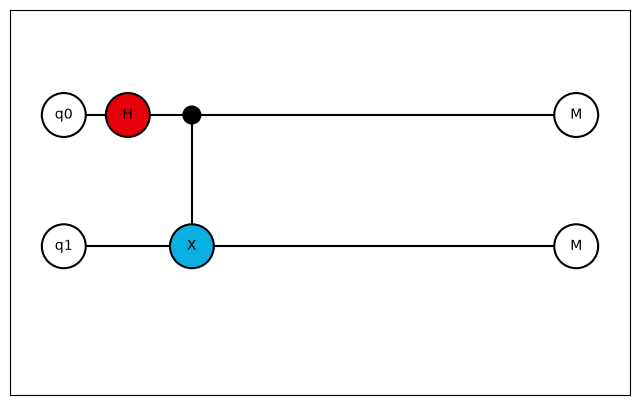

({0: [{'num': 0,
    'gate': 'q0',
    'angle': '',
    'xpos': 0,
    'ypos': 0.0,
    'type': 'qubit'},
   {'num': 2,
    'gate': 'H',
    'angle': '',
    'xpos': 1,
    'ypos': 0.0,
    'type': 'gate'},
   {'num': 4, 'gate': '', 'angle': '', 'xpos': 2, 'ypos': 0.0, 'type': 'gate'},
   {'num': 5,
    'gate': 'M',
    'angle': '',
    'xpos': 8,
    'ypos': 0.0,
    'type': 'measurement'}],
  1: [{'num': 1,
    'gate': 'q1',
    'angle': '',
    'xpos': 0,
    'ypos': 1.5,
    'type': 'qubit'},
   {'num': 3,
    'gate': 'X',
    'angle': '',
    'xpos': 2,
    'ypos': 1.5,
    'type': 'gate'},
   {'num': 6,
    'gate': 'M',
    'angle': '',
    'xpos': 8,
    'ypos': 1.5,
    'type': 'measurement'}]},
 2,
 [2, 3, 5],
 [1, 2, 3],
 [(3, 4)],
 [])

In [16]:
Circuit().h[0].cx[0,1].m[:].run(backend="draw")

これで '00' と '11' がそれぞれ約半分の回数で得られます。もしこれが単に各量子ビットの重ね合わせ状態の積

$$
\ket{\psi^\prime} = (\ket{0} + \ket{1})(\ket{0} + \ket{1})/2\\
= (\ket{00} + \ket{01} + \ket{10} + \ket{11})/2
$$

であったなら、例えば {'00':25, '01':25, '10':25, '11':25} に近い結果が得られていたはずです。

## GHZ状態: 3量子ビットのエンタングルメント
グリーンバーガー・ホーン・ツァイリンガー(GHZ)状態は、次のような3量子ビットからなるエンタングル状態です。
$$
\ket{GHZ} = (\ket{000} + \ket{111})/\sqrt{2}
$$
この状態は以下の回路で作ることができます。

In [17]:
Circuit().h[0].cx[0,1].cx[1,2].m[:].run(shots=100)

Counter({'000': 50, '111': 50})

約半分が '000'、残り半分が '111' となります。

# 量子アルゴリズム

### 概要

アルゴリズムとは一般に、コンピュータがある問題を解くために実行する手順のことを指します。

量子アルゴリズムとは、量子コンピュータ上で実行されるように設計されたアルゴリズムです。
ブラケット記号を用いた数学的な表現で記述されることが多いですが、最終的には具体的な量子ゲートを使った量子回路に落とし込まれます。

量子アルゴリズムの狙いは、量子コンピュータを用いることで、古典コンピュータより高速な計算を行うこと、あるいは物理的な制約(メモリ容量など)のために古典コンピュータでは事実上不可能な計算を行うことです。
これは量子ビットの重ね合わせとエンタングルメントという性質を利用することで達成されます。
(古典的な)ビットと異なり、$n$ 量子ビットは同時に $2^n$ 個の重ね合わせ状態を保持できます。

一見すると、$2^n$ 個の計算を並列に実行できると考えたくなりますが、残念ながらそう単純ではありません。
なぜなら、量子コンピュータでは「測定」というプロセスによって $2^n$ 個の状態のうちの1つだけが確率的に出力されるからです。
言い換えると、量子コンピュータは内部に膨大な量の情報を保持できますが、出力できる情報は非常に限られています。
したがって、量子アルゴリズムは少ない出力回数で望みの解を得意に得られるように設計する必要があります。

現在のところ、量子アルゴリズムが古典アルゴリズムより高速であることが示されている計算は、非常に限られた数しかありません。
その限られた例の中には、有名なショアのアルゴリズムとグローバーのアルゴリズムが含まれます。
これらのアルゴリズムを学ぶ過程で、量子コンピュータが古典コンピュータに対して優位性を持ちそうな計算の種類を把握できるようになるでしょう。
量子アルゴリズムをより高速にするような新しい計算の発見が、将来の量子コンピュータ利用の原動力となるでしょう。

### NISQアルゴリズム

現在(2021年)の量子コンピュータはまだ規模が小さく、ノイズが計算結果に与える影響も無視できません。このような量子コンピュータは、Noisy Intermediate-Scale Quantum (NISQ)デバイス[1]として区別されます。
上記のような、理論的に古典アルゴリズムより高速であることが示されている量子アルゴリズムは、実用的な規模と精度ではNISQデバイス上で実行することができません。
これを実現できる量子コンピュータ(大規模で誤り耐性のある量子コンピュータ)の開発には、数十年かかると言われています。

一方で、「量子超越」として発表された現在最大級のNISQデバイスは、既存の古典コンピュータでは効率的にシミュレートできない領域に到達しています[2]。
したがって、数十年を待たなくても、NISQデバイスを使うことで既存の古典コンピュータより高速に実行できる計算が出てくると期待されます。
このようなアルゴリズムはNISQアルゴリズムと呼ばれ、現在世界中で研究開発競争が行われています。

### NISQアルゴリズムと非NISQアルゴリズムの学習について
以降のチュートリアルでは、非NISQアルゴリズム(「汎用量子アルゴリズム」)とNISQアルゴリズムを区別して扱います。
量子回路の基本的な構成や使用する量子ゲートはどちらも同じです。
非NISQアルゴリズムと比較して、NISQアルゴリズムは少ない量子ビット数で動作し、計算の誤りに対する耐性を重視します。

非NISQ量子アルゴリズムは、量子計算がどのように古典計算より高速になり得るかを見るという点で、学習に適していると言えます。
一方、近い将来における量子コンピュータの実用的な利用に焦点を当てたい場合は、NISQアルゴリズムを調べることが有用でしょう。

### 参考文献

[1] Bharti, Kishor, et al. "Noisy intermediate-scale quantum (NISQ) algorithms." arXiv preprint arXiv:2101.08448 (2021).  
[2] Arute, Frank, et al. "Quantum supremacy using a programmable superconducting processor." Nature 574.7779 (2019): 505-51  
[3] Nielsen, Chuang "Quantum Computation and Quantum Information" Cambridge university press.